# Homework 3

## Consegna

 ### 1. Regressione lineare semplice polinomiale

Dati $(xi, yi), i = 1, . . . n$ approssimare i dati mediante un modello dato
dalla funzione polinomiale:

$$
f(x, \alpha) = \sum_{k=0}^d a_k x^k,
$$

Scrivere un codice python che risolve il problema dei minimi quadrati
lineari.

$$
\min || X\alpha - y ||_2^2
$$

secondo le notazioni utilizzate a lezione (X è la matrice di Vandermonde)
con la fattorizzazione SVD.


Inclusione librerie

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

Creazione del problema test

In [70]:
def problem_1(n, d, sigma=0.1, alpha=None):
    if alpha is None:
        alpha = np.random.randn(d + 1)

    x = np.linspace(0, 1, n)

    def f_poly(x, coefficients):
        y = np.zeros_like(x)
        for k, a_k in enumerate(coefficients):
            y += a_k * (x ** k)
        return y

    e = np.random.normal(loc=0, scale=sigma, size=n)

    y = f_poly(x, alpha) + e
    return x, y, alpha, f_poly

Test del codice precedente

In [71]:
def plot(n = 50, d_approx = 3, alpha = None):
    x, y, alpha, f_poly = problem_1(n, d_approx, sigma=0.1, alpha=alpha)
    print(f"Grado d: {d_approx}")
    print(f"Coefficienti alpha: {alpha}")
    print(f"Primi 5 valori di x: {x[:5]}")
    print(f"Primi 5 valori di y: {y[:5]}")

    plt.scatter(x, y, color='red', label='Dati rumorosi $y_i$', s=15)
    plt.plot(x, f_poly(x, alpha), color='blue', label='Polinomio vero $f(x, \\alpha)$', alpha=0.5)
    plt.legend()
    plt.title(f"Problema Test (d={d_approx}, $\\sigma$=0.1)")
    plt.show()


Grado d: 10
Coefficienti alpha: [ 0.5 -1.2  2.5  1. ]
Primi 5 valori di x: [0.         0.02040816 0.04081633 0.06122449 0.08163265]
Primi 5 valori di y: [0.52918416 0.58037835 0.61908765 0.41410219 0.49817315]


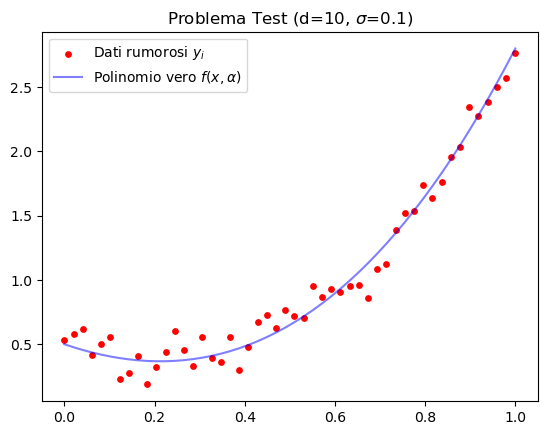

Grado d: 1
Coefficienti alpha: [-0.02899122  0.63531602]
Primi 5 valori di x: [0.         0.02564103 0.05128205 0.07692308 0.1025641 ]
Primi 5 valori di y: [-1.45438425e-01 -1.42253668e-01  4.12604751e-02 -2.72473104e-02
  2.01976707e-05]


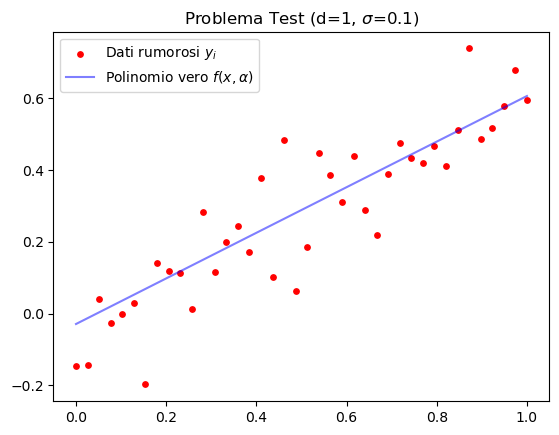

Grado d: 3
Coefficienti alpha: [ 1.15702074  0.54062548 -0.31018847 -0.6633808 ]
Primi 5 valori di x: [0.         0.02564103 0.05128205 0.07692308 0.1025641 ]
Primi 5 valori di y: [0.97675383 1.05105518 1.10060922 1.22684848 1.21543005]


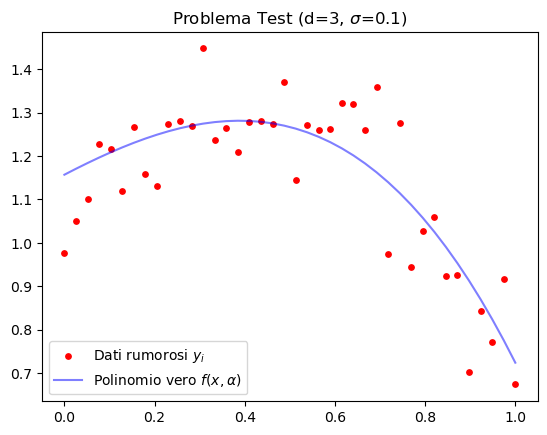

Grado d: 12
Coefficienti alpha: [ 0.16824591 -1.13328405  1.48063185  0.23718481  1.20764459 -0.00371143
  0.04408978 -0.39780448 -1.71276373  2.24097055 -1.2204901   1.61133965
  0.87466043]
Primi 5 valori di x: [0.         0.07142857 0.14285714 0.21428571 0.28571429]
Primi 5 valori di y: [ 0.1821562   0.06195455  0.09871425  0.0588426  -0.18377394]


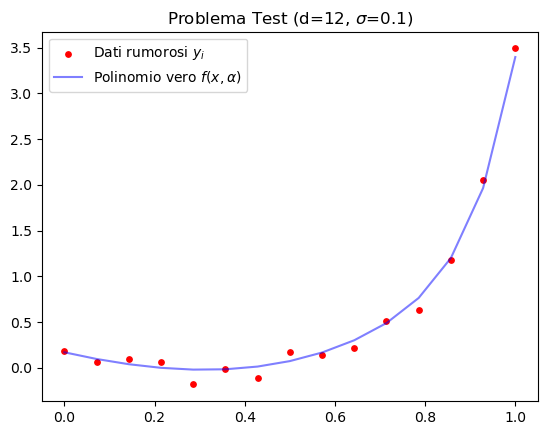

In [72]:
plot(50, 10, alpha=np.array([0.5, -1.2, 2.5, 1.0]))
plot(40, 1)
plot(40, 3)
plot(15, 12)

--- Analisi Dataset: submission.csv ---
Numero campioni: 1459
Grado d=1 -> MSE: 6.0837e+09, R²=0.0014)
Grado d=3 -> MSE: 6.0464e+09, R²=0.0075)
Grado d=5 -> MSE: 6.0349e+09, R²=0.0094)
Grado d=15 -> MSE: 4.7923e+09, R²=0.2134)
Grado d=100 -> MSE: 4.4951e+09, R²=0.2622)


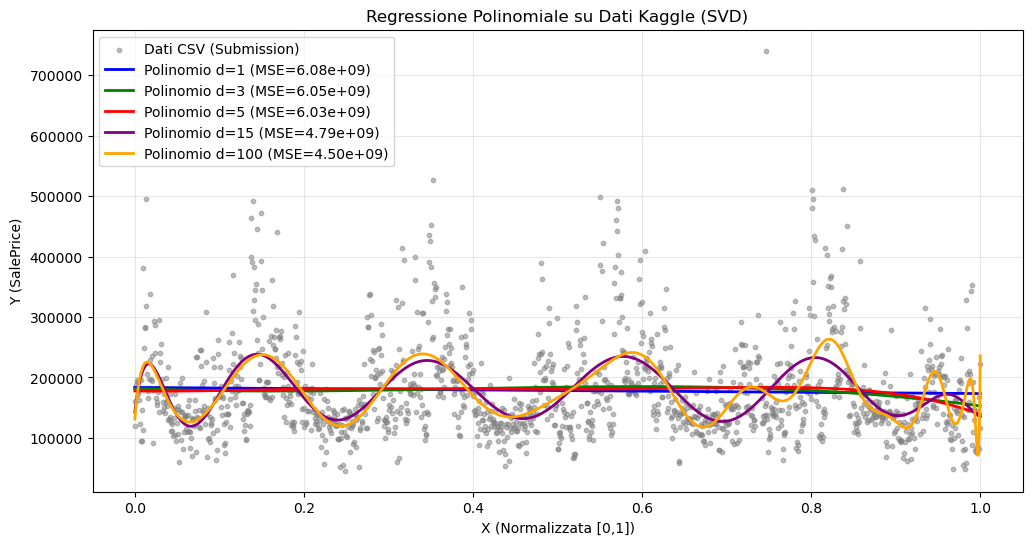

In [73]:
def build_vandermonde(x, d):
    return np.vander(x, N=d + 1, increasing=True)


def solve_ls_svd(X, y):
    U, s, Vt = sp.linalg.svd(X, full_matrices=False)

    threshold = 1e-12
    s_inv = np.zeros_like(s)
    mask = s > threshold
    s_inv[mask] = 1.0 / s[mask]

    uty = U.T @ y
    s_uty = s_inv * uty
    alpha = Vt.T @ s_uty

    return alpha


def poly_eval(x, alpha):
    d = len(alpha) - 1
    X = build_vandermonde(x, d)
    return X @ alpha


def load_and_normalize_csv(csv_path):
    df = pd.read_csv(csv_path)

    x_raw = df.iloc[:, 0].values.astype(float)
    y_raw = df.iloc[:, 1].values.astype(float)

    sort_idx = np.argsort(x_raw)
    x_sorted = x_raw[sort_idx]
    y_sorted = y_raw[sort_idx]

    x_min, x_max = np.min(x_sorted), np.max(x_sorted)
    x_norm = (x_sorted - x_min) / (x_max - x_min)

    return x_norm, y_sorted, x_raw


def analyze_csv_regression(csv_path, degrees_to_test):
    x, y, x_original = load_and_normalize_csv(csv_path)

    plt.figure(figsize=(12, 6))

    plt.scatter(x, y, color='gray', alpha=0.5, s=10, label='Dati CSV (Submission)')

    colors = ['blue', 'green', 'red', 'purple', 'orange']

    print(f"--- Analisi Dataset: {csv_path} ---")
    print(f"Numero campioni: {len(x)}")

    for i, d in enumerate(degrees_to_test):
        X_mat = build_vandermonde(x, d)

        alpha = solve_ls_svd(X_mat, y)

        y_pred = poly_eval(x, alpha)

        mse = np.mean((y - y_pred) ** 2)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)

        r2 = 1 - (ss_res / ss_tot)
        print(f"Grado d={d} -> MSE: {mse:.4e}, R²={r2:.4f})")
        
        color = colors[i % len(colors)]
        plt.plot(x, y_pred, color=color, linewidth=2, label=f'Polinomio d={d} (MSE={mse:.2e})')

        

    plt.title("Regressione Polinomiale su Dati Kaggle (SVD)")
    plt.xlabel("X (Normalizzata [0,1])")
    plt.ylabel("Y (SalePrice)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


file_name = "submission.csv"

analyze_csv_regression(file_name, degrees_to_test=[1, 3, 5, 15, 100])



 ### 2. Regressione lineare multipla

Scrivere un codice python per realizzare una regressione lineare multipla
utilizzando le funzioni della libreria Pandas e scikit-learn.



Librerie aggiuntive

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


Funzioni richieste


--- REGRESSIONE LINEARE MULTIPLA ---
Dataset: kc_house_data_NaN.csv | Shape: (21597, 21) | Target: prezzo

[Modello Completo] R2: 0.6914 | MSE: 40144359438.3941

--- Ablation Study (Importanza Features) ---
Feature                   | Delta R2  
----------------------------------------
Unnamed: 0                | 0.00036
id                        | -0.00026
camere                    | 0.00336
bagni                     | 0.00201
superficie_abitabile      | 0.00000
superficie_lotto          | 0.00024
piani                     | -0.00009
vista_mare                | 0.01696
vista_panorama            | 0.01015
condizione                | 0.00081
grado_di_qualità          | 0.02533
superficie_sopra          | 0.00000
superficie_seminterrato   | 0.00000
anno_costruzione          | 0.01587
anno_ristrutturazione     | 0.00048
cap                       | 0.00559
latitudine                | 0.05324
longitudine               | 0.00454
superficie_abitabile_15   | -0.00026
superficie_lotto_15      

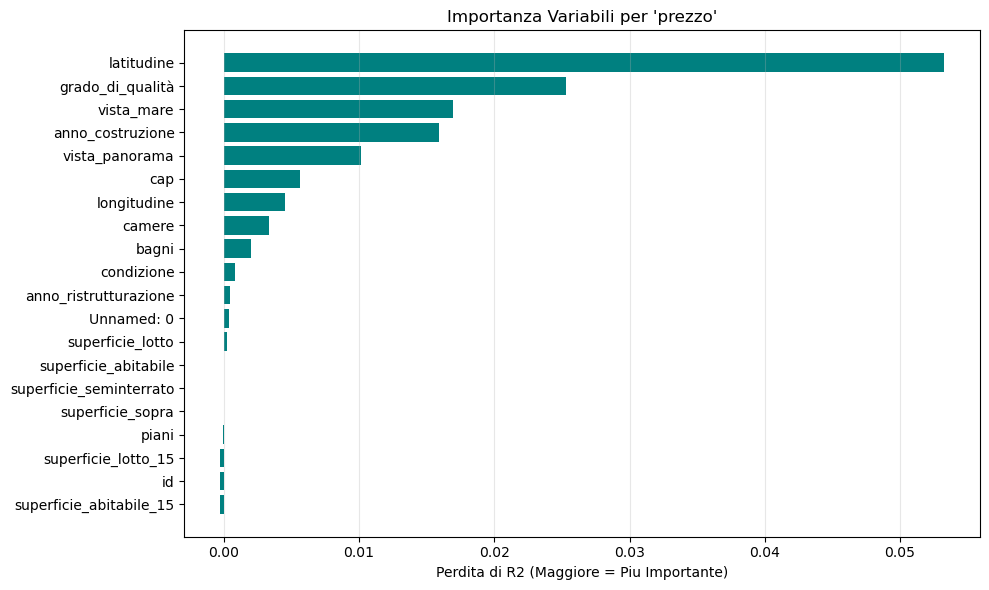

In [75]:
def run_multiple_regression_analysis():
    print("\n--- REGRESSIONE LINEARE MULTIPLA ---")

    filename = "kc_house_data_NaN.csv"
    df = pd.read_csv(filename)

    df = df.select_dtypes(include=[np.number]).dropna()

    target_col = next((c for c in df.columns if c.lower() == 'prezzo'), df.columns[-1])

    X = df.drop(columns=[target_col])
    y = df[target_col]

    print(f"Dataset: {filename} | Shape: {df.shape} | Target: {target_col}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model_full = LinearRegression()
    model_full.fit(X_train, y_train)
    y_pred_full = model_full.predict(X_test)

    r2_full = r2_score(y_test, y_pred_full)
    mse_full = mean_squared_error(y_test, y_pred_full)

    print(f"\n[Modello Completo] R2: {r2_full:.4f} | MSE: {mse_full:.4f}")

    print("\n--- Ablation Study (Importanza Features) ---")
    print(f"{'Feature':<25} | {'Delta R2':<10}")
    print("-" * 40)

    results = []

    for feature in X.columns:
        model_sub = LinearRegression()
        model_sub.fit(X_train.drop(columns=[feature]), y_train)

        r2_sub = model_sub.score(X_test.drop(columns=[feature]), y_test)

        delta_r2 = r2_full - r2_sub
        results.append((feature, delta_r2))

        print(f"{feature:<25} | {delta_r2:.5f}")

    results.sort(key=lambda x: x[1], reverse=True)
    features, deltas = zip(*results)

    plt.figure(figsize=(10, 6))
    plt.barh(features, deltas, color='teal')
    plt.xlabel("Perdita di R2 (Maggiore = Piu Importante)")
    plt.title(f"Importanza Variabili per '{target_col}'")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


run_multiple_regression_analysis()